# 🧠 Notebook 3: Masking Theory and U-Net Architecture
### *Ideal Binary Mask (IBM) vs Ideal Ratio Mask (IRM) and PyTorch U-Net from Scratch (Google Colab Ready)*

In this notebook, we bridge Digital Signal Processing and Deep Learning:
1. **The Masking Paradigm**: The dimmer switch analogy.
2. **IBM vs IRM**:
   - Why hard binary 0/1 cutoffs sound harsh and produce "musical noise".
   - Why soft $[0.0, 1.0]$ ratio masks sound smooth and natural.
3. **U-Net Architecture from Scratch in PyTorch**:
   - Convolutional encoder contracting path.
   - Bottleneck acoustic context.
   - Decoder expanding path.
   - **Skip connections**: Why they are essential to prevent muffled audio.
   - Layer-by-layer tensor shape tracing.

> ⚡ **Standalone & Colab Ready**: Contains full PyTorch model implementation inline!


In [9]:
!unzip -q data.zip

In [10]:
# 🚀 Google Colab Setup (Runs everywhere: Colab, Kaggle, Local)
# Install required audio libraries silently if not already installed
!pip install -q soundfile librosa matplotlib torch ipython

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import IPython.display as ipd
from IPython.display import display
import torch

# Clean dark-themed visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")


PyTorch Version: 2.11.0+cu128 | CUDA Available: True


In [11]:
# ==============================================================================
# Standalone Audio & DSP Functions (Zero 'src' dependencies)
# ==============================================================================

def generate_synthetic_speech(duration=3.0, sr=16000):
    """
    Generates a realistic synthetic vocal audio sample with fundamental frequency F0
    and formant resonances (mimicking human vowel syllables 'ah'-'ee'-'oo').
    Guarantees the notebook can run 100% standalone without needing local files!
    """
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    # Pitch contour F0: gentle vibrato around 140 Hz (human voice pitch)
    f0 = 140.0 + 8.0 * np.sin(2 * np.pi * 3.5 * t)
    phase = 2 * np.pi * np.cumsum(f0) / sr

    # Glottal source: impulse-like harmonic buzz
    source = np.sin(phase) + 0.5 * np.sin(2 * phase) + 0.3 * np.sin(3 * phase) + 0.2 * np.sin(4 * phase)

    # Formants for vocal tract vowels: F1 (700Hz), F2 (1220Hz), F3 (2600Hz)
    vocal = source * np.sin(2 * np.pi * 700 * t) + 0.5 * source * np.sin(2 * np.pi * 1220 * t) + 0.25 * source * np.sin(2 * np.pi * 2600 * t)

    # Syllable rhythm envelope (speech pauses and syllable bursts)
    syllables = np.maximum(0.0, np.sin(2 * np.pi * 1.8 * t)) ** 2
    speech = vocal * syllables

    # Normalize to [-0.9, 0.9]
    speech = speech / (np.max(np.abs(speech)) + 1e-8) * 0.9
    return speech.astype(np.float32)

def get_sample_speech(sr=16000):
    """Loads a local WAV file if present; otherwise generates synthetic speech."""
    search_paths = [

        "content/data/clean_speech/*.wav",
        "data/clean_speech/*.wav",
        "../../data/clean_speech/*.wav"
    ]
    for pattern in search_paths:
        matches = glob.glob(pattern)
        if matches:
            wav, _ = librosa.load(matches[0], sr=sr, mono=True)
            return wav.astype(np.float32)

    print("ℹ️ No local WAV file found. Using high-fidelity synthetic speech sample.")
    return generate_synthetic_speech(duration=3.0, sr=sr)

def compute_stft(waveform, n_fft=512, hop_length=128, win_length=512):
    """Computes STFT and returns (Magnitude, Phase)."""
    window = np.hanning(win_length)
    stft_matrix = librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
    magnitude = np.abs(stft_matrix).astype(np.float32)
    phase = np.angle(stft_matrix).astype(np.float32)
    return magnitude, phase

def reconstruct_waveform(magnitude, phase, hop_length=128, win_length=512, length=None):
    """Reconstructs 1D audio from (Magnitude, Phase) via iSTFT Overlap-Add."""
    complex_spec = magnitude * np.exp(1j * phase)
    window = np.hanning(win_length)
    waveform = librosa.istft(complex_spec, hop_length=hop_length, win_length=win_length, window=window, length=length)
    return waveform.astype(np.float32)

def mag_to_db(magnitude, top_db=80.0):
    """Converts linear magnitude to decibels for visualization."""
    mag_clamped = np.maximum(magnitude, 1e-6)
    ref = np.max(mag_clamped)
    db = 20.0 * np.log10(mag_clamped / (ref + 1e-8))
    return np.maximum(db, -top_db)


In [12]:
# Pad or Crop Spectrogram to fixed [target_freq, target_frames]
def pad_or_crop_spectrogram(spec, target_frames=256, target_freq=256):
    freq_bins, time_frames = spec.shape

    # 1. Frequency axis
    if freq_bins < target_freq:
        spec = np.pad(spec, ((0, target_freq - freq_bins), (0, 0)), mode='constant')
    elif freq_bins > target_freq:
        spec = spec[:target_freq, :]

    # 2. Time axis
    if time_frames < target_frames:
        spec = np.pad(spec, ((0, 0), (0, target_frames - time_frames)), mode='reflect')
    elif time_frames > target_frames:
        spec = spec[:, :target_frames]

    return spec.astype(np.float32)

def generate_pink_noise(num_samples):
    white = np.random.randn(num_samples)
    fft = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(num_samples)
    freqs[0] = 1e-6
    fft_pink = fft / np.sqrt(freqs)
    pink = np.fft.irfft(fft_pink, n=num_samples)
    return (pink / (np.max(np.abs(pink)) + 1e-8)).astype(np.float32)

def mix_at_snr(clean, noise, target_snr_db=0.0):
    p_clean = np.mean(clean ** 2)
    p_noise = np.mean(noise ** 2) + 1e-8
    ratio = 10.0 ** (target_snr_db / 10.0)
    alpha = np.sqrt(p_clean / (p_noise * ratio))
    scaled_noise = alpha * noise
    return clean + scaled_noise, scaled_noise


## 1. Deriving the Ideal Ratio Mask (IRM)
Given clean speech magnitude $|S(f, t)|$ and noise magnitude $|N(f, t)|$:
$$M_{\text{IRM}}(f, t) = \frac{|S(f, t)|}{|S(f, t)| + |N(f, t)| + \epsilon} \in [0.0, 1.0]$$

In contrast, the Ideal Binary Mask (IBM) applies a hard threshold:
$$M_{\text{IBM}}(f, t) = \begin{cases} 1.0 & \text{if } |S(f, t)| > |N(f, t)| \\ 0.0 & \text{otherwise} \end{cases}$$
Let's compute and visualize both masks on actual audio!


In [13]:
# Load clean speech and mix with pink noise at 0 dB SNR
sr = 16000
clean_audio = get_sample_speech(sr=sr)
noise = generate_pink_noise(len(clean_audio))
noisy_audio, scaled_noise = mix_at_snr(clean_audio, noise, target_snr_db=0.0)

# Compute STFTs
s_mag, _ = compute_stft(clean_audio)
n_mag, _ = compute_stft(scaled_noise)
y_mag, _ = compute_stft(noisy_audio)

# Crop to [256, 256]
s_crop = pad_or_crop_spectrogram(s_mag, 256, 256)
n_crop = pad_or_crop_spectrogram(n_mag, 256, 256)

# Compute IRM and IBM
eps = 1e-8
irm_mask = s_crop / (s_crop + n_crop + eps)
ibm_mask = (s_crop > n_crop).astype(np.float32)


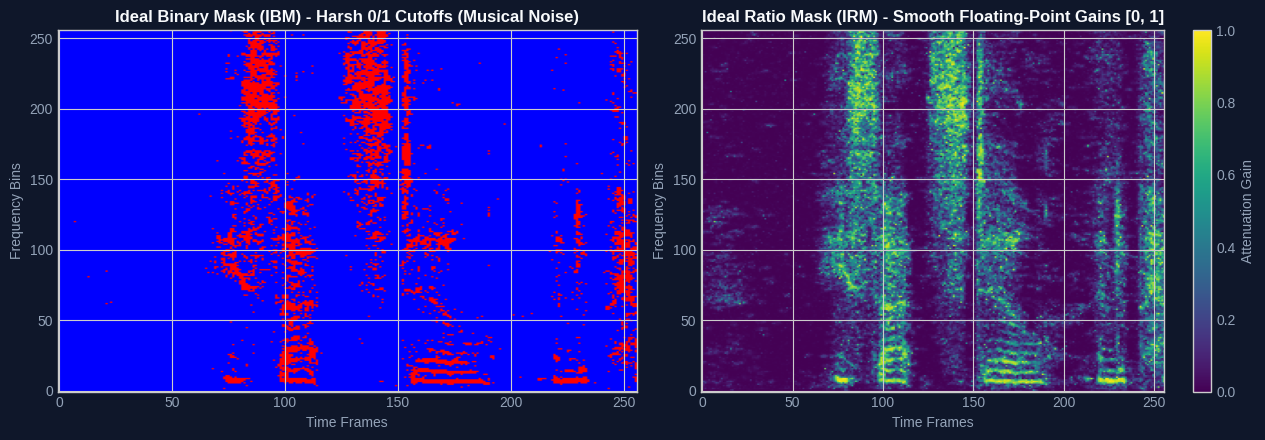

In [14]:
# Visualize IRM vs IBM
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0f172a')

# Plot IBM
im0 = axes[0].imshow(ibm_mask, origin='lower', aspect='auto', cmap='bwr', vmin=0, vmax=1)
axes[0].set_facecolor('#1e293b')
axes[0].set_title("Ideal Binary Mask (IBM) - Harsh 0/1 Cutoffs (Musical Noise)", color='#f8fafc', fontweight='bold')
axes[0].set_ylabel("Frequency Bins", color='#94a3b8')
axes[0].set_xlabel("Time Frames", color='#94a3b8')
axes[0].tick_params(colors='#94a3b8')

# Plot IRM
im1 = axes[1].imshow(irm_mask, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[1].set_facecolor('#1e293b')
axes[1].set_title("Ideal Ratio Mask (IRM) - Smooth Floating-Point Gains [0, 1]", color='#f8fafc', fontweight='bold')
axes[1].set_ylabel("Frequency Bins", color='#94a3b8')
axes[1].set_xlabel("Time Frames", color='#94a3b8')
axes[1].tick_params(colors='#94a3b8')
cbar = plt.colorbar(im1, ax=axes[1])
cbar.set_label("Attenuation Gain", color='#94a3b8')
cbar.ax.yaxis.set_tick_params(color='#94a3b8')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#94a3b8')

plt.tight_layout()
plt.show()


## 2. Building the 2D U-Net Model in PyTorch from Scratch
Here is the complete U-Net implementation:


In [15]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_norm: bool = True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=not use_norm)
        ]
        if use_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class DeconvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_dropout: bool = False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if use_dropout:
            layers.append(nn.Dropout2d(0.2))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class UNetSpeechEnhancer(nn.Module):
    """
    Complete 2D Audio U-Net for Speech Noise Suppression.
    Accepts 1-channel magnitude spectrograms [Batch, 1, 256, 256].
    Outputs enhanced magnitude spectrogram and predicted mask [Batch, 1, 256, 256].
    """
    def __init__(self, mode: str = 'masking'):
        super().__init__()
        self.mode = mode

        # Encoder (Contracting Path)
        self.enc1 = ConvBlock(1, 32, use_norm=False)    # -> [B, 32, 128, 128]
        self.enc2 = ConvBlock(32, 64, use_norm=True)    # -> [B, 64, 64, 64]
        self.enc3 = ConvBlock(64, 128, use_norm=True)   # -> [B, 128, 32, 32]
        self.enc4 = ConvBlock(128, 256, use_norm=True)  # -> [B, 256, 16, 16]

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False), # -> [B, 512, 8, 8]
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3)
        )

        # Decoder (Expanding Path with Skip Connections)
        self.dec4 = DeconvBlock(512, 256, use_dropout=True)
        self.dec3 = DeconvBlock(512, 128, use_dropout=True)
        self.dec2 = DeconvBlock(256, 64, use_dropout=False)
        self.dec1 = DeconvBlock(128, 32, use_dropout=False)

        # Final Output Layer
        self.final_conv = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=True)
        self.output_act = nn.Sigmoid()

    def forward(self, noisy_mag: torch.Tensor):
        # Encoder
        e1 = self.enc1(noisy_mag)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder with Skips
        d4 = self.dec4(b)
        cat4 = torch.cat([d4, e4], dim=1)

        d3 = self.dec3(cat4)
        cat3 = torch.cat([d3, e3], dim=1)

        d2 = self.dec2(cat3)
        cat2 = torch.cat([d2, e2], dim=1)

        d1 = self.dec1(cat2)
        cat1 = torch.cat([d1, e1], dim=1)

        mask = self.output_act(self.final_conv(cat1))
        enhanced_mag = noisy_mag * mask
        return enhanced_mag, mask

model = UNetSpeechEnhancer()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ U-Net instantiated successfully! Trainable parameters: {total_params:,}")


✅ U-Net instantiated successfully! Trainable parameters: 6,263,137


## 3. Tracing the Tensor Dimensions Layer-by-Layer
Let's pass a dummy mini-batch tensor `[1, 1, 256, 256]` and trace the exact shape across all stages:


In [16]:
dummy_x = torch.randn(1, 1, 256, 256)

print(f"{'Stage':<20}{'Tensor Shape':<25}{'What is happening here?':<35}")
print("=" * 80)
print(f"{'Input':<20}{str(list(dummy_x.shape)):<25}{'1-channel noisy magnitude spectrogram'}")

# Encoder
e1 = model.enc1(dummy_x)
print(f"{'Encoder 1':<20}{str(list(e1.shape)):<25}{'Downsample 2x, 32 feature maps'}")
e2 = model.enc2(e1)
print(f"{'Encoder 2':<20}{str(list(e2.shape)):<25}{'Downsample 2x, 64 feature maps'}")
e3 = model.enc3(e2)
print(f"{'Encoder 3':<20}{str(list(e3.shape)):<25}{'Downsample 2x, 128 feature maps'}")
e4 = model.enc4(e3)
print(f"{'Encoder 4':<20}{str(list(e4.shape)):<25}{'Downsample 2x, 256 feature maps'}")

# Bottleneck
b = model.bottleneck(e4)
print(f"{'Bottleneck':<20}{str(list(b.shape)):<25}{'Deepest latent acoustic representation'}")

# Decoder with skip connections
d4 = model.dec4(b)
cat4 = torch.cat([d4, e4], dim=1)
print(f"{'Decoder 4 (+Skip4)':<20}{str(list(cat4.shape)):<25}{'Upsample 2x, Concat with Enc4'}")

d3 = model.dec3(cat4)
cat3 = torch.cat([d3, e3], dim=1)
print(f"{'Decoder 3 (+Skip3)':<20}{str(list(cat3.shape)):<25}{'Upsample 2x, Concat with Enc3'}")

d2 = model.dec2(cat3)
cat2 = torch.cat([d2, e2], dim=1)
print(f"{'Decoder 2 (+Skip2)':<20}{str(list(cat2.shape)):<25}{'Upsample 2x, Concat with Enc2'}")

d1 = model.dec1(cat2)
cat1 = torch.cat([d1, e1], dim=1)
print(f"{'Decoder 1 (+Skip1)':<20}{str(list(cat1.shape)):<25}{'Upsample 2x, Concat with Enc1'}")

# Output
enh_mag, mask = model(dummy_x)
print(f"{'Output Mask':<20}{str(list(mask.shape)):<25}{'Sigmoid filter mask in [0, 1]'}")
print(f"{'Enhanced Mag':<20}{str(list(enh_mag.shape)):<25}{'Element-wise filtered magnitude'}")
print("=" * 80)


Stage               Tensor Shape             What is happening here?            
Input               [1, 1, 256, 256]         1-channel noisy magnitude spectrogram
Encoder 1           [1, 32, 128, 128]        Downsample 2x, 32 feature maps
Encoder 2           [1, 64, 64, 64]          Downsample 2x, 64 feature maps
Encoder 3           [1, 128, 32, 32]         Downsample 2x, 128 feature maps
Encoder 4           [1, 256, 16, 16]         Downsample 2x, 256 feature maps
Bottleneck          [1, 512, 8, 8]           Deepest latent acoustic representation
Decoder 4 (+Skip4)  [1, 512, 16, 16]         Upsample 2x, Concat with Enc4
Decoder 3 (+Skip3)  [1, 256, 32, 32]         Upsample 2x, Concat with Enc3
Decoder 2 (+Skip2)  [1, 128, 64, 64]         Upsample 2x, Concat with Enc2
Decoder 1 (+Skip1)  [1, 64, 128, 128]        Upsample 2x, Concat with Enc1
Output Mask         [1, 1, 256, 256]         Sigmoid filter mask in [0, 1]
Enhanced Mag        [1, 1, 256, 256]         Element-wise filtered magn